In [26]:
# =====================================
# IMPORT LIBRARIES
# =====================================

import matplotlib
matplotlib.use('Agg')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [27]:
# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("/crop_yield_dataset.csv")

In [28]:
# =====================================
# HANDLE MISSING VALUES
# =====================================

df['Previous_Crop'] = df['Previous_Crop'].fillna('None')
df['Irrigation'] = df['Irrigation'].fillna('Unknown')


In [29]:
# =====================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =====================================

# 1. Yield Distribution
plt.figure()
plt.hist(df['Yield_ton_per_ha'], bins=30)
plt.xlabel("Yield (ton/ha)")
plt.ylabel("Frequency")
plt.title("Distribution of Crop Yield")
plt.savefig("yield_distribution.png")
plt.close()

In [30]:
# 2. Crop-wise Average Yield
avg_yield = df.groupby('Crop')['Yield_ton_per_ha'].mean()
plt.figure()
plt.bar(avg_yield.index, avg_yield.values)
plt.xlabel("Crop")
plt.ylabel("Average Yield")
plt.title("Average Yield by Crop")
plt.savefig("avg_yield_by_crop.png")
plt.close()

In [31]:
# 3. Rainfall vs Yield
plt.figure()
plt.scatter(df['Rainfall_mm'], df['Yield_ton_per_ha'])
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (ton/ha)")
plt.title("Rainfall vs Yield")
plt.savefig("rainfall_vs_yield.png")
plt.close()

In [32]:
# 4. Fertilizer vs Yield
plt.figure()
plt.scatter(df['Fertilizer_Used_kg'], df['Yield_ton_per_ha'])
plt.xlabel("Fertilizer Used (kg)")
plt.ylabel("Yield (ton/ha)")
plt.title("Fertilizer Usage vs Yield")
plt.savefig("fertilizer_vs_yield.png")
plt.close()

In [33]:
# 5. Boxplot: Yield by Irrigation
plt.figure()
df.boxplot(column='Yield_ton_per_ha', by='Irrigation')
plt.xlabel("Irrigation Method")
plt.ylabel("Yield")
plt.title("Yield by Irrigation Method")
plt.suptitle("")
plt.savefig("yield_by_irrigation_boxplot.png")
plt.close()


In [34]:
# 6. Boxplot: Yield by Crop
plt.figure()
df.boxplot(column='Yield_ton_per_ha', by='Crop')
plt.xlabel("Crop")
plt.ylabel("Yield")
plt.title("Yield by Crop")
plt.suptitle("")
plt.savefig("yield_by_crop_boxplot.png")
plt.close()

In [35]:
# =====================================
# CORRELATION MATRIX
# =====================================

num_cols = []
num_cols.append('Soil_pH')
num_cols.append('Rainfall_mm')
num_cols.append('Temperature_C')
num_cols.append('Humidity_pct')
num_cols.append('Fertilizer_Used_kg')
num_cols.append('Pesticides_Used_kg')
num_cols.append('Planting_Density')

corr_data = df[num_cols + ['Yield_ton_per_ha']]
corr_matrix = corr_data.corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.close()


In [36]:
# =====================================
# FEATURE & TARGET SELECTION
# =====================================

X = df.drop('Yield_ton_per_ha', axis=1)
y = df['Yield_ton_per_ha']

cat_cols = []
cat_cols.append('Crop')
cat_cols.append('Region')
cat_cols.append('Soil_Type')
cat_cols.append('Irrigation')
cat_cols.append('Previous_Crop')


In [37]:
# =====================================
# ENCODING & SCALING
# =====================================

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cat = encoder.fit_transform(X[cat_cols])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

scaler = StandardScaler()
scaled_num = scaler.fit_transform(X[num_cols])

scaled_num_df = pd.DataFrame(
    scaled_num,
    columns=num_cols
)

X_processed = pd.concat(
    [scaled_num_df.reset_index(drop=True),
     encoded_cat_df.reset_index(drop=True)],
    axis=1
)

In [38]:
# =====================================
# TRAIN-TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
# =====================================
# MODEL TRAINING
# =====================================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [40]:
# =====================================
# MODEL EVALUATION (REGRESSION METRICS)
# =====================================

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Regression Evaluation Metrics")
print("--------------------------------")
print("R2 Score:", round(r2, 3))
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))

Regression Evaluation Metrics
--------------------------------
R2 Score: 0.98
MAE: 4.307
MSE: 28.755
RMSE: 5.362


In [41]:
# =====================================
# ACTUAL vs PREDICTED
# =====================================

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.savefig("actual_vs_predicted.png")
plt.close()

In [42]:
# =====================================
# FEATURE IMPORTANCE (SIMPLE WAY)
# =====================================

feature_importance_df = pd.DataFrame()
feature_importance_df['Feature'] = X_processed.columns
feature_importance_df['Importance'] = model.feature_importances_

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features Affecting Yield")
plt.gca().invert_yaxis()
plt.savefig("feature_importance.png")
plt.close()


In [43]:
# =====================================
# PREDICT NEW DATA
# =====================================

new_data = pd.DataFrame({
    'Soil_pH': [6.5],
    'Rainfall_mm': [850],
    'Temperature_C': [28],
    'Humidity_pct': [70],
    'Fertilizer_Used_kg': [120],
    'Pesticides_Used_kg': [25],
    'Planting_Density': [1800],
    'Crop': ['Rice'],
    'Region': ['South'],
    'Soil_Type': ['Loamy'],
    'Irrigation': ['Drip'],
    'Previous_Crop': ['Wheat']
})

new_cat = encoder.transform(new_data[cat_cols])
new_cat_df = pd.DataFrame(
    new_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

new_num = scaler.transform(new_data[num_cols])
new_num_df = pd.DataFrame(
    new_num,
    columns=num_cols
)

new_processed = pd.concat(
    [new_num_df.reset_index(drop=True),
     new_cat_df.reset_index(drop=True)],
    axis=1
)

prediction = model.predict(new_processed)

print("Predicted Yield (ton/ha):", round(prediction[0], 2))

Predicted Yield (ton/ha): 88.49



--- yield_distribution.png ---


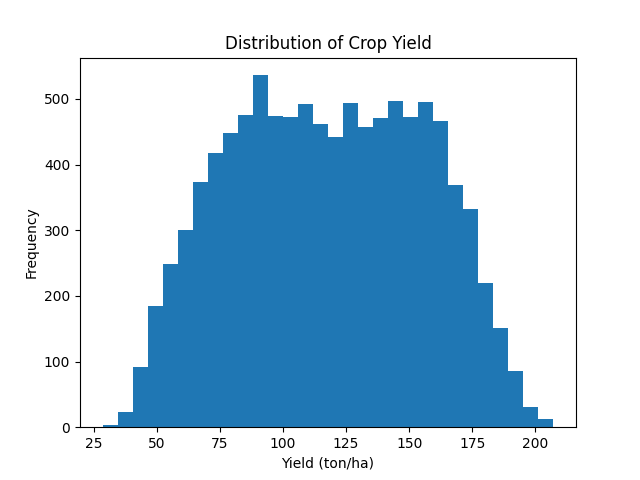


--- avg_yield_by_crop.png ---


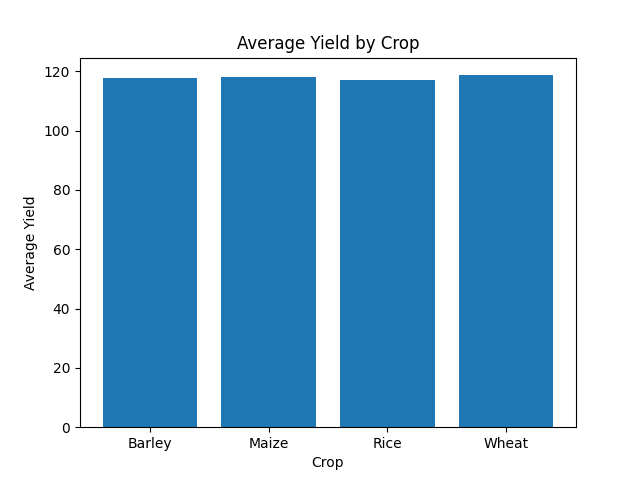


--- rainfall_vs_yield.png ---


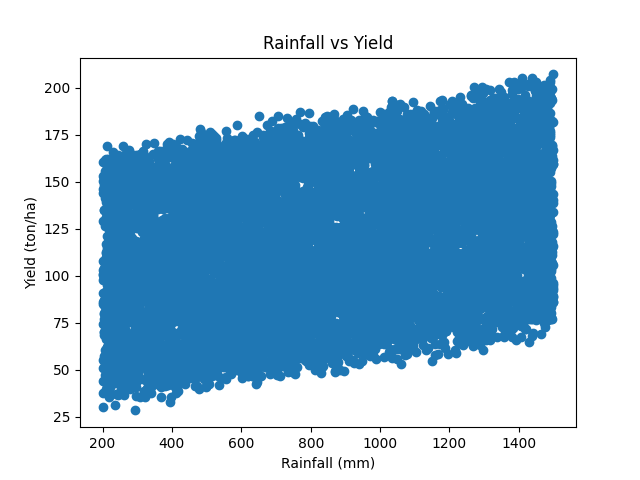


--- fertilizer_vs_yield.png ---


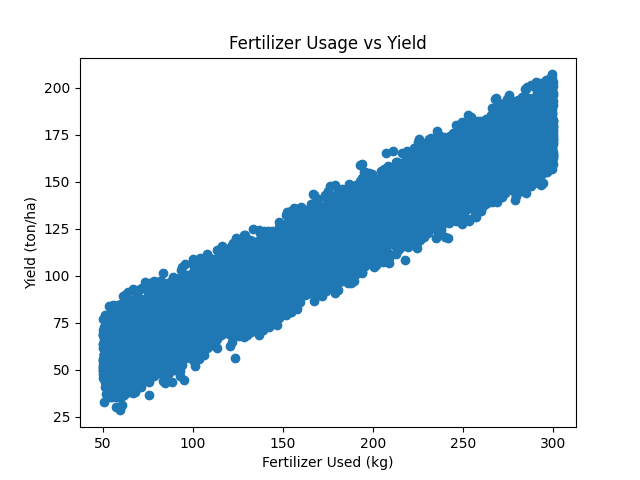


--- yield_by_irrigation_boxplot.png ---


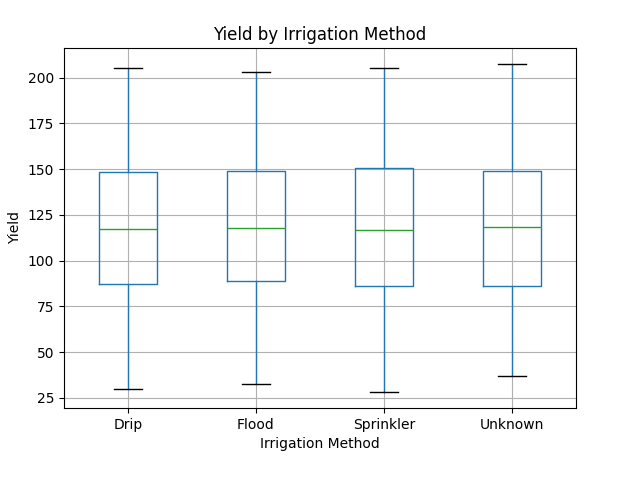


--- yield_by_crop_boxplot.png ---


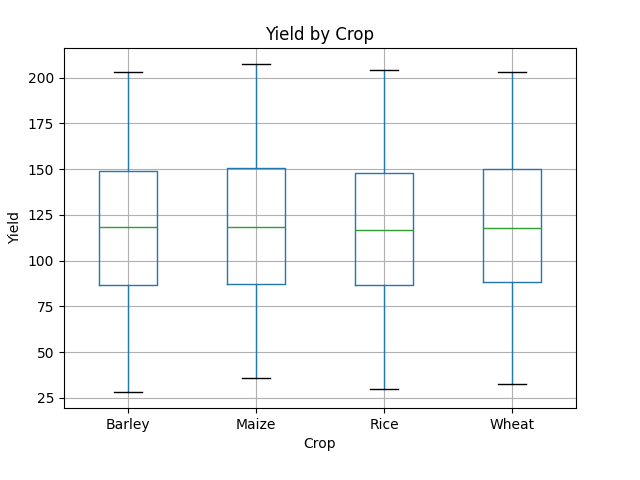


--- correlation_matrix.png ---


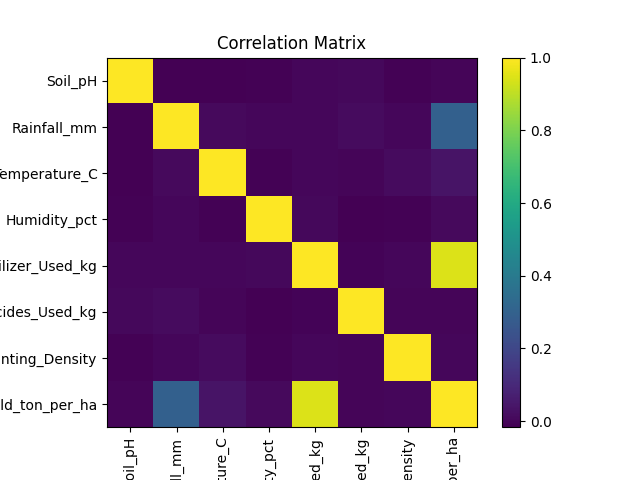


--- actual_vs_predicted.png ---


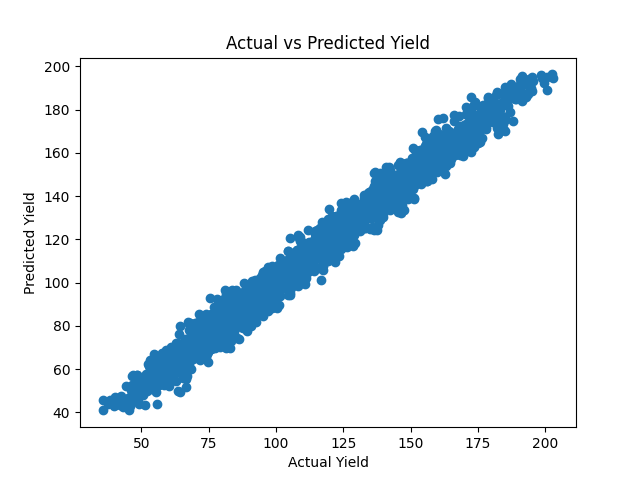


--- feature_importance.png ---


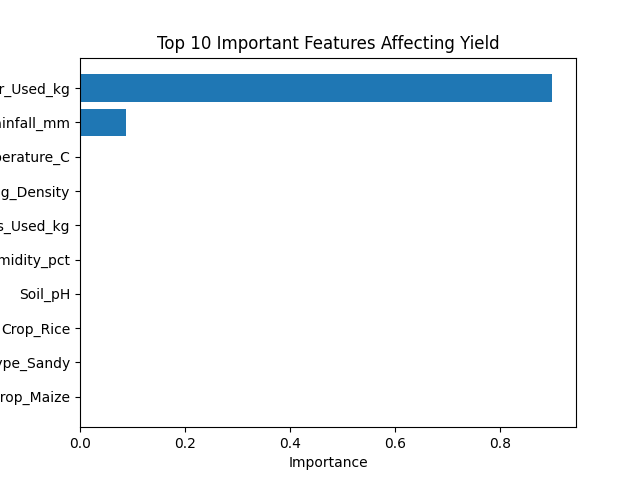

In [44]:
from IPython.display import Image, display

image_files = [
    "yield_distribution.png",
    "avg_yield_by_crop.png",
    "rainfall_vs_yield.png",
    "fertilizer_vs_yield.png",
    "yield_by_irrigation_boxplot.png",
    "yield_by_crop_boxplot.png",
    "correlation_matrix.png",
    "actual_vs_predicted.png",
    "feature_importance.png"
]

for img in image_files:
    print(f"\n--- {img} ---")
    display(Image(filename=img))